## Lastprofile EFH


In [87]:

import numpy as np
import richardsonpy.classes.occupancy as occ
import richardsonpy.functions.change_resolution as cr
import richardsonpy.functions.load_radiation as loadrad
import richardsonpy.classes.electric_load as eload
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import pandas as pd

from demandlib import bdew
import random


## Einladen der Netzdaten

In [58]:
busse = gpd.read_parquet("data/netz_parquets/busse.parquet" )
kabel= gpd.read_parquet("data/netz_parquets/kabel.parquet")
busse

,geometry,IDENTNUMME,NUTZUNG,KNOTENTYP,LEISTUNG,BAUFORM
0,POINT (568319.778 6003416.482),6B0402-302,SAS,MUFFE,0.0,None
1,POINT (568214.928 6003382.617),6B0402-041,SHB_20KV,NETZSTATION,630.0,None
3,POINT (568197.75 6003386.727),6B0402-125,SHB,MUFFE,0.0,None
4,POINT (568213.464 6003318.008),6B4100-003,SHB,KVS,0.0,6-REIHIG
5,POINT (568117.207 6003363.454),6B0402-209,SHB,MUFFE,0.0,None
6,POINT (568231.324 6003372.195),6B0402-043,SHB,MUFFE,0.0,None
7,POINT (568293.621 6003393.373),6B0402-037,SHB,MUFFE,0.0,None
8,POINT (568052.899 6003322.593),6B0402-017,SHB,KVS,0.0,6-REIHIG
9,POINT (568341.43 6003430.614),6B0402-272,SAB,HA,0.0,None
10,POINT (568280.942 6003488.267),6B0402-282,SAB,HA,0.0,None


## Welche Knoten sind eigentlich alles die Anschlussknoten im Netz?

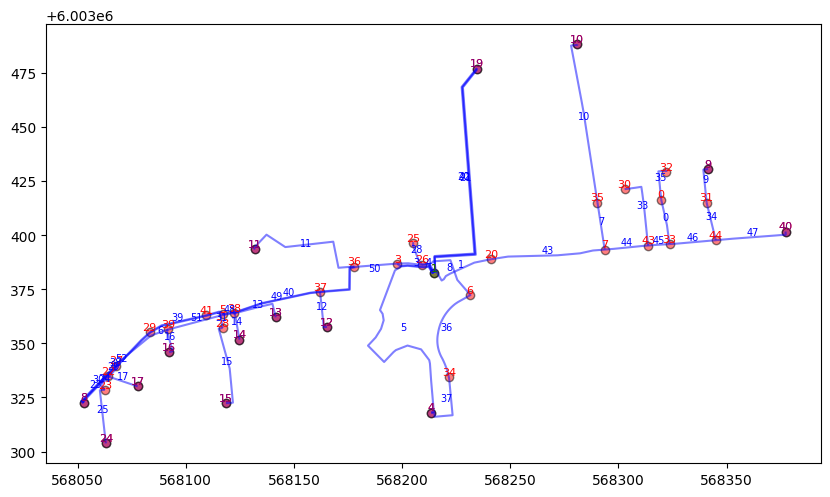

In [59]:
fig, ax = plt.subplots(figsize=(10, 10))

kabel.plot(ax=ax, color='blue', alpha=0.5, edgecolor='k', label='Lines')
busse.plot(ax=ax, color='red', alpha=0.5, edgecolor='k', label='Busses')
trafo_bus = busse[busse["IDENTNUMME"] == "6B0402-041"]
trafo_bus.plot(ax=ax, color='green', alpha=0.5, edgecolor='k', label='Busses')
anschluss_busse = busse[busse["KNOTENTYP"].isin(["HA", "KVS"])]
anschluss_busse.plot(ax=ax, color="purple", alpha=0.5, edgecolor='k', label='AP')

# Bus-Index
for idx, row in busse.iterrows():
    ax.annotate(
        text=str(idx),
        xy=(row.geometry.x, row.geometry.y),
        fontsize=8,
        color='red',
        ha='center',
        va='bottom'
    )
    
# Bus-Index
for idx, row in trafo_bus.iterrows():
    ax.annotate(
        text=str(idx),
        xy=(row.geometry.x, row.geometry.y),
        fontsize=8,
        color='green',
        ha='center',
        va='bottom'
    )
    
# Bus-Index
for idx, row in anschluss_busse.iterrows():
    ax.annotate(
        text=str(idx),
        xy=(row.geometry.x, row.geometry.y),
        fontsize=8,
        color='purple',
        ha='center',
        va='bottom'
    )
    


# Line-Index – Centroid des LineStrings nutzen
for idx, row in kabel.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=str(idx),
        xy=(centroid.x, centroid.y),
        fontsize=7,
        color='blue',
        ha='center',
        va='bottom'
    )

In [60]:
#  Total number of occupants within apartment
number_occupants = 3

#  Generate occupancy object instance
occupancy_object = occ.Occupancy(number_occupants=number_occupants)

#  Pointer to occupancy profile
occupancy_profile = occupancy_object.occupancy

In [61]:
def stoch_el_load(nb_occ, sfh, step):

    #  Generate occupancy object (necessary as input for electric load gen.)
    occ_obj = occ.Occupancy(number_occupants=nb_occ)

    (q_direct, q_diffuse) = loadrad.get_rad_from_try_path("TRY2010_03_Jahr.dat")

    #  Convert 3600 s timestep to given timestep
    # q_direct = cr.change_resolution(q_direct, old_res=3600, new_res=timestep)
    # q_diffuse = cr.change_resolution(q_diffuse, old_res=3600, new_res=timestep)

    #  Generate stochastic electric load object instance
    el_load_obj = eload.ElectricLoad(occ_profile=occ_obj.occupancy,
                                     total_nb_occ=nb_occ,
                                     q_direct=q_direct,
                                     q_diffuse=q_diffuse,
                                     timestep=step,
                                     is_sfh=sfh)
    
    load_curve = el_load_obj.loadcurve / 1000 # in kWh
    return load_curve


## Profile für gewerblich genutzte Gebäude

G0  → Gewerbe allgemein
G1  → Gewerbe werktags 8-18 Uhr (Bürobetriebe)
G2  → Gewerbe mit starkem Abend-/Wochenendverbrauch
       (z.B. Sportvereine, Schützenvereine)
G3  → Gewerbe durchlaufend (kontinuierlicher Betrieb)
G4  → Laden/Friseur
G5  → Bäckerei mit Backstube
G6  → Wochenendbetrieb (z.B. Diskotheken, Kinos)

In [62]:
def non_res_profiles(slp_type, annual_demand):
    # Stromprofil
    e_slp = bdew.ElecSlp(year=2018)
    elec_profile = e_slp.get_scaled_power_profiles(
        ann_el_demand_per_sector={slp_type: annual_demand}
    ).resample("h").mean()
    return np.array(elec_profile).transpose()[0]

In [63]:
stoch_el_load(3, True, 3600)

array([0.052     , 0.052     , 0.21722077, ..., 3.03398262, 0.19844199,
       0.052     ], shape=(8760,))

## Quellen für Stromverbräuche für verschiedene Gewerbe
Quelle: https://www.oegut.at/downloads/pdf/e_kennzahlen-ev-dlg_zb.pdf
Supermarkt: 150+183= 333 kWh/m2/a * A
Einzelhandel: 49 kWh/m2/a * A
Gastro: 135 kWh/m2/a * A

Quelle: Studie: Energieeffizienz im Einzelhandel (PDF) EHI
Food: 358 kWh/m2/a
Non-Food: 123 kWh/m2/a

Quelle Fraunhofer GHD 2013
Food: 130 kWh/m2/a
Non-Food: 47 kWh/m2/a


In [64]:
empty_profile = np.array([float(0) for n in range(8760)])

# AP 10
2x EFH mit 2 Occ

In [65]:
num_buil = 2
num_occ = 2

profile_10 = empty_profile.copy()

for n in range(2):
    buil_profile = stoch_el_load(num_occ, True, 3600)
    profile_10 += buil_profile

## AP 35
1x Bäckerei


In [66]:
a_back = 150
back_bedarf = 135 * a_back

profile_35 = non_res_profiles("g5", back_bedarf)
profile_35

array([0.92057386, 0.88348114, 1.02292596, ..., 1.14074989, 1.06874638,
       1.06894474], shape=(8760,))

## AP 30 
1x EFH mit 3 Occ


In [67]:
num_occ = 3
profile_30 = stoch_el_load(num_occ, True, 3600)

## AP 32
1x EFH

In [68]:
num_occ = 3
profile_32 = stoch_el_load(num_occ, True, 3600)

## AP 9
1x EFH

In [69]:
num_occ = 3
profile_9 = stoch_el_load(num_occ, True, 3600)

# AP 40
KVS Osten

Keine Lasten, da im Osten auch zwei Trafos sind = keine Versorgung dieses Bereichs

## AP 4
KVS Süden
77x EFH mit 2-4 Occ

In [70]:
profile_4 = empty_profile.copy()

for n in range(77):
    num_occ = random.choice([2, 3, 4])
    buil_profile = stoch_el_load(num_occ, True, 3600)
    profile_4 += buil_profile

## AP 19
EDEKA

In [85]:
a_edeka = 400

edeka_bedarf = 333 * a_edeka
profile_19 = non_res_profiles("g3", edeka_bedarf)
profile_19

array([12.5004892 , 13.05221486, 12.38935022, ..., 14.30914381,
       13.74154116, 12.87624481], shape=(8760,))

## AP 24
1x EFH

In [72]:
num_occ = 3
profile_24 = stoch_el_load(num_occ, True, 3600)

## AP 8
1x EFH

In [73]:
num_occ = 3
profile_8 = stoch_el_load(num_occ, True, 3600)

## AP 12

1x Döner
1x EFH mit 4 Occ


In [74]:
num_occ = 4

a_doener = 60
doener_bedarf = 135 * a_doener

# Dönerladen
profile_12 = non_res_profiles("g2", doener_bedarf)

# EFH
buil_profile = stoch_el_load(num_occ, True, 3600)

profile_12 += buil_profile


## AP 13

1x Elektrofachmarkt + 1x EFH 2 Occ



In [ ]:
num_occ = 3
a_emarkt= 60
emarkt_bedarf = 49 * a_emarkt

# EFH
buil_profile = stoch_el_load(num_occ, True, 3600)

# E-MArkt
profile_13 = non_res_profiles("g2", emarkt_bedarf)

profile_13 += buil_profile


## AP 14

1x Fachmarkt + 1x EFH 2 Occ

In [ ]:
a_markt = 60
markt_bedarf = 49 * a_markt
occ_num = 2
# China restaurant
profile_14 = non_res_profiles("g2", markt_bedarf)

# EFH
num_occ = 3
buil_profile = stoch_el_load(num_occ, True, 3600)

profile_14 += buil_profile

## AP 15
1x Gewerbehalle
Muss nochmal näher nachgeschuat werden annahme lagerhalle

In [77]:
a_halle = 700
halle_bedarf = 30 * a_halle

profile_15 = non_res_profiles("g3", halle_bedarf)

## AP 16
1x China Restaurant + 1x EFH 3 Occ

In [ ]:
num_occ = 3
a_china= 120 
china_bedarf = 135 * a_china
print(china_bedarf)
# China restaurant
profile_16 = non_res_profiles("g2", china_bedarf)

# EFH
buil_profile = stoch_el_load(num_occ, True, 3600)

profile_16 += buil_profile

16200
[1.02206655 0.63547346 0.53025836 ... 3.40822916 2.53497602 1.69148555]
[ 0.048       2.303       0.12       ... 10.43363161  0.41314858
  0.41404715]


## AP 17
1x EFH mit 3 Occ

In [79]:
num_occ = 3
profile_17 = stoch_el_load(num_occ, True, 3600)

## Gesamtprofil am Trafo ohne E-Autos

In [86]:
profil_trafo = profile_10 + profile_12 + profile_13 + profile_14 + profile_15 + profile_4 + profile_16 + profile_17 + profile_24 + profile_30 + profile_35 + profile_8 + profile_32 + profile_9 + profile_19
profil_trafo.max()

np.float64(181.45103693906023)

In [88]:
# Datetime Index für 2018 (stündlich)
datetime_index = pd.date_range(start="2018-01-01", end="2018-12-31 23:00", freq="h")

# DataFrame mit allen Profilen
load_df = pd.DataFrame({
    "profile_4":  profile_4,
    "profile_8":  profile_8,
    "profile_9":  profile_9,
    "profile_10": profile_10,
    "profile_12": profile_12,
    "profile_13": profile_13,
    "profile_14": profile_14,
    "profile_15": profile_15,
    "profile_16": profile_16,
    "profile_17": profile_17,
    "profile_19": profile_19,
    "profile_24": profile_24,
    "profile_30": profile_30,
    "profile_32": profile_32,
    "profile_35": profile_35,
}, index=datetime_index)


In [89]:
load_df

,profile_4,profile_8,profile_9,profile_10,profile_12,profile_13,profile_14,profile_15,profile_16,profile_17,profile_19,profile_24,profile_30,profile_32,profile_35
2018-01-01 00:00:00,3.829000,0.044000,0.046,0.109000,0.564033,0.242486,0.236486,1.970798,1.070067,0.056000,12.500489,0.060000,0.054000,0.049000,6.904362
2018-01-01 01:00:00,7.508639,0.044000,0.046,0.133000,0.370737,0.172327,0.461103,2.057782,2.938473,0.056000,13.052215,0.060000,0.054000,0.049000,7.209095
2018-01-01 02:00:00,5.400274,0.044000,0.046,0.408582,0.318129,0.153232,0.147232,1.953276,0.650258,0.228188,12.389350,0.060000,0.123000,0.049000,6.842977
2018-01-01 03:00:00,5.699356,0.066331,0.046,0.208092,0.306385,0.148969,0.142969,1.839175,1.121770,0.056000,11.665624,0.060000,0.054000,0.049000,6.443243
2018-01-01 04:00:00,5.816505,0.044000,0.046,0.208092,0.305018,0.148473,0.142473,1.765958,0.552035,0.056000,11.201222,0.060000,0.054000,0.049000,6.186741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,80.618308,0.309873,0.129,1.967081,2.370261,3.350438,1.057654,2.941178,4.090342,0.217000,18.655472,0.182000,2.360607,0.257000,10.303927
2018-12-31 20:00:00,72.528271,0.229512,0.046,0.730832,2.336979,2.158165,1.154357,2.448479,4.246403,0.276000,15.530350,0.182000,0.450064,0.284966,8.577836
2018-12-31 21:00:00,87.376179,0.220000,0.046,3.973482,2.009579,1.959122,0.880530,2.255946,13.841861,0.176000,14.309144,0.144000,0.387309,2.104000,7.903331
2018-12-31 22:00:00,84.659196,0.336000,0.046,3.906509,6.301354,0.980080,0.928162,2.166459,2.948125,2.928949,13.741541,0.242171,0.447064,0.121000,7.589829
